<a href="https://colab.research.google.com/github/Lunarawake/CSE144_Final_Project/blob/main/CSE144FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE 144 Final Project — Transfer Learning

**Team members:** Tianai Shang, Esther Cui


## 0. Mount Google Drive & Install Dependencies

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import os

BASE_DIR  = '/content/drive/MyDrive/ucsc-cse-144-spring-2026-final-project'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
SAMPLE_SUBMISSION = os.path.join(BASE_DIR, 'sample_submission.csv')

print('train:', os.listdir(TRAIN_DIR)[:5])
print('test files:', len(os.listdir(TEST_DIR)))

train: ['98', '99', '97', '95', '91']
test files: 1036


## 1. Imports & Reproducibility Seed

In [45]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models
from PIL import Image
import pandas as pd
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## 2. Hyperparameters

In [46]:
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 30
LR_HEAD      = 1e-3
LR_BACKBONE  = 1e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 100
VAL_SPLIT    = 0.15

MODEL_NAME = 'efficientnet_b3'

## 3. Data Transforms & Dataset

In [47]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_dataset.classes = sorted(full_dataset.classes, key=lambda x: int(x))
full_dataset.class_to_idx = {cls: int(cls) for cls in full_dataset.classes}
full_dataset.targets = [int(Path(s[0]).parent.name) for s in full_dataset.samples]

print(f'Total training images: {len(full_dataset)}')
print(f'Classes (first 5): {full_dataset.classes[:5]}')
print(f'Class to index (first 5): {dict(list(full_dataset.class_to_idx.items())[:5])}')

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
val_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {train_size} | Val: {val_size}')

Total training images: 1079
Classes (first 5): ['0', '1', '2', '3', '4']
Class to index (first 5): {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Train: 918 | Val: 161


## 4. Model Definition

In [48]:
def build_model(model_name: str, num_classes: int):
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_params = model.fc.parameters()
        backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        head_params = model.classifier.parameters()
        backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]

    elif model_name == 'efficientnet_b3':
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        head_params = model.classifier.parameters()
        backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]

    else:
        raise ValueError(f'Unknown model: {model_name}')

    return model, head_params, backbone_params


model, head_params, backbone_params = build_model(MODEL_NAME, NUM_CLASSES)
model = model.to(DEVICE)
print(f'Model: {MODEL_NAME} loaded on {DEVICE}')

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Model: efficientnet_b3 loaded on cuda
Total parameters: 10,849,932


## 5. Optimizer, Scheduler & Loss

In [49]:
optimizer = optim.AdamW([
    {'params': head_params,     'lr': LR_HEAD},
    {'params': backbone_params, 'lr': LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print('Optimizer, scheduler, and loss function ready.')

Optimizer, scheduler, and loss function ready.


## 6. Training Loop

In [50]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


best_val_acc = 0.0
SAVE_PATH = '/content/best_model.pth'
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}'
          + (' ← best' if val_acc == best_val_acc else ''))

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch   1/30 | Train Loss: 4.3274, Acc: 0.0882 | Val Loss: 3.7679, Acc: 0.1988 ← best
Epoch   2/30 | Train Loss: 3.2855, Acc: 0.3039 | Val Loss: 3.0081, Acc: 0.3416 ← best
Epoch   3/30 | Train Loss: 2.5675, Acc: 0.5207 | Val Loss: 2.5301, Acc: 0.4472 ← best
Epoch   4/30 | Train Loss: 2.0905, Acc: 0.6569 | Val Loss: 2.3417, Acc: 0.4783 ← best
Epoch   5/30 | Train Loss: 1.8054, Acc: 0.7364 | Val Loss: 2.1649, Acc: 0.5217 ← best
Epoch   6/30 | Train Loss: 1.5883, Acc: 0.7778 | Val Loss: 2.0893, Acc: 0.5404 ← best
Epoch   7/30 | Train Loss: 1.3868, Acc: 0.8606 | Val Loss: 1.9912, Acc: 0.5963 ← best
Epoch   8/30 | Train Loss: 1.2948, Acc: 0.8943 | Val Loss: 1.9644, Acc: 0.6025 ← best
Epoch   9/30 | Train Loss: 1.2170, Acc: 0.9194 | Val Loss: 1.9645, Acc: 0.5652
Epoch  10/30 | Train Loss: 1.1454, Acc: 0.9401 | Val Loss: 1.9443, Acc: 0.5839
Epoch  11/30 | Train Loss: 1.1040, Acc: 0.9488 | Val Loss: 1.9205, Acc: 0.5901
Epoch  12/30 | Train Loss: 1.0830, Acc: 0.9542 | Val Loss: 1.9185, Acc: 0.5

## 7. Plot Training Curves

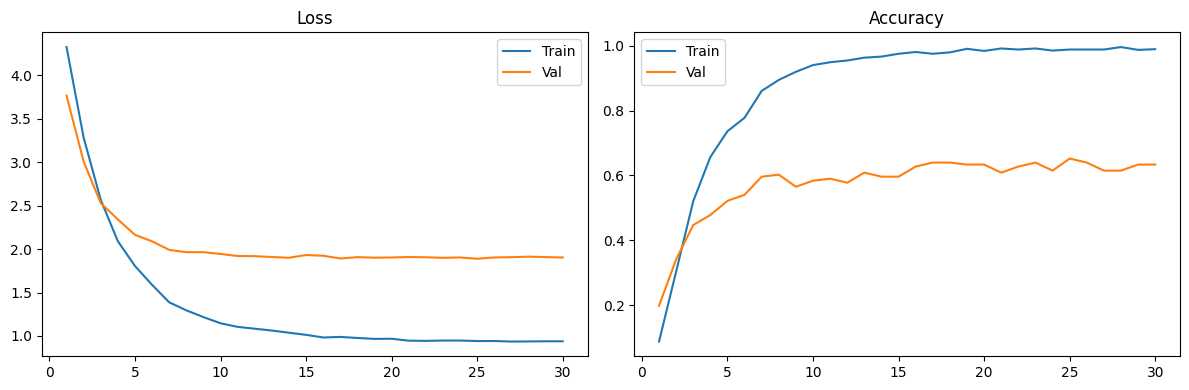

Saved to /content/training_curves.png


In [51]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Saved to /content/training_curves.png')

## 8. Generate Predictions & submission.csv

In [52]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_files = sorted(os.listdir(TEST_DIR), key=lambda x: int(x.split('.')[0]))

predictions = []
with torch.no_grad():
    for fname in test_files:
        img_path = os.path.join(TEST_DIR, fname)
        img = Image.open(img_path).convert('RGB')
        tensor = test_transform(img).unsqueeze(0).to(DEVICE)
        pred = model(tensor).argmax(1).item()
        predictions.append(pred)

new_df = pd.DataFrame({'ID': test_files, 'Label': predictions})
new_df.to_csv('/content/submission.csv', index=False)
print(f'Total predictions: {len(new_df)}')
print(new_df.head())

Total predictions: 1036
      ID  Label
0  0.jpg     63
1  1.jpg     38
2  2.jpg     32
3  3.jpg     59
4  4.jpg     37


## 9. Save Model Weights to Google Drive

In [53]:
import shutil

DRIVE_SAVE_DIR = '/content/drive/MyDrive/cse144_outputs'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

shutil.copy(SAVE_PATH, os.path.join(DRIVE_SAVE_DIR, 'best_model.pth'))
shutil.copy(SUBMISSION_PATH, os.path.join(DRIVE_SAVE_DIR, 'submission.csv'))
shutil.copy('/content/training_curves.png', os.path.join(DRIVE_SAVE_DIR, 'training_curves.png'))

print(f'Files saved to Google Drive: {DRIVE_SAVE_DIR}')

Files saved to Google Drive: /content/drive/MyDrive/cse144_outputs
